# EDA: ST Education, Employment, and Poverty Across High-ST States

## Main Question

**How do differences in educational outcomes among Scheduled Tribe populations relate to employment and poverty across high-ST states in India, and which states require different policy priorities?**

## Core Supporting Questions

1. How do ST literacy and literacy gaps describe long-term educational exclusion?
2. Do states with stronger ST schooling participation, measured by GER, also have lower dropout and lower ST poverty?
3. Are enrolment and GER enough to indicate educational progress, or do dropout rates tell a different story?
4. Is the literacy gap more informative than ST literacy alone in explaining disadvantage?
5. Are there states where educational indicators look reasonable, but employment or poverty outcomes remain weak?
6. Does MGNREG unmet demand reflect deeper livelihood distress among ST households?

## Additional Questions

7. Does secondary dropout appear to be a stronger warning signal of poverty and weak labour outcomes than literacy alone?
8. Do high-ST-share states systematically perform worse, or do outcomes vary substantially?
9. Do states with high concentrations of ST villages show different education and livelihood outcomes?
10. Are there gender-specific disadvantages hidden behind state averages?

In [1]:
from pathlib import Path
import math
import sqlite3
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats

ROOT = Path.cwd()
if not (ROOT / "outputs").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)

OUTPUTS = ROOT / "outputs"
DB_PATH = OUTPUTS / "st_education_project.sqlite"

plt.rcParams["figure.figsize"] = (8.5, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.2

print("Project root:", ROOT)

Project root: C:\Users\yuvra\OneDrive\Desktop\spring 2026\DSM\Final


## Rebuild Data and EDA Outputs

The raw files remain unchanged. This cell rebuilds the cleaned tables and derived outputs before the notebook reads them.

In [2]:
import scripts.build_project_data as build_project_data
import scripts.run_policy_eda as run_policy_eda

build_project_data.main()
run_policy_eda.main()

Processed 14 datasets
Wrote cleaned CSVs to outputs\cleaned
Wrote analysis outputs to outputs\analysis
Wrote SQLite database to outputs\st_education_project.sqlite


Wrote EDA tables to outputs\eda\tables
Wrote EDA figures to outputs\eda\figures
Wrote EDA report to outputs\eda\eda_policy_report.md


## Load Main Tables

In [3]:
high_st = pd.read_csv(OUTPUTS / "analysis" / "state_analysis_dataset_high_st_states.csv").copy()
all_states = pd.read_csv(OUTPUTS / "analysis" / "state_analysis_dataset_all_states.csv").copy()
inventory = pd.read_csv(OUTPUTS / "analysis" / "data_inventory.csv")

# Keep notebook logic conservative. Clean only what is needed for readable plots.
for col in ["ger_classes_i_viii", "ger_classes_ix_xii"]:
    clean_col = f"{col}_clean"
    high_st[clean_col] = high_st[col].where(high_st[col].between(0, 500))
    all_states[clean_col] = all_states[col].where(all_states[col].between(0, 500))

high_st["female_literacy_gap_pct"] = (
    high_st["tribe_weighted_literacy_male_pct"] - high_st["tribe_weighted_literacy_female_pct"]
)
all_states["female_literacy_gap_pct"] = (
    all_states["tribe_weighted_literacy_male_pct"] - all_states["tribe_weighted_literacy_female_pct"]
)

high_st["villages_gt50_per_100k_st_pop"] = (
    high_st["tribal_villages_gt_50_count"] / high_st["st_population"] * 100000
)
all_states["villages_gt50_per_100k_st_pop"] = (
    all_states["tribal_villages_gt_50_count"] / all_states["st_population"] * 100000
)

print(f"High-ST states: {high_st.shape[0]} rows")
print(f"All-state master table: {all_states.shape[0]} rows")

High-ST states: 19 rows
All-state master table: 34 rows


In [4]:
def corr_frame(df, x_cols, y_cols, sample_name):
    rows = []
    for x in x_cols:
        for y in y_cols:
            subset = df[[x, y]].dropna()
            if len(subset) < 4:
                continue
            r, p = stats.pearsonr(subset[x], subset[y])
            rows.append(
                {
                    "sample": sample_name,
                    "x": x,
                    "y": y,
                    "n": len(subset),
                    "pearson_r": round(float(r), 4),
                    "pearson_p": round(float(p), 4),
                    "abs_r": round(abs(float(r)), 4),
                }
            )
    return pd.DataFrame(rows).sort_values("abs_r", ascending=False).reset_index(drop=True)


def compare_predictors(df, predictors, outcomes):
    rows = []
    for outcome in outcomes:
        scores = []
        for predictor in predictors:
            subset = df[[predictor, outcome]].dropna()
            if len(subset) < 4:
                continue
            r, p = stats.pearsonr(subset[predictor], subset[outcome])
            scores.append((predictor, len(subset), r, p, abs(r)))
        if not scores:
            continue
        scores = sorted(scores, key=lambda x: x[4], reverse=True)
        best = scores[0]
        second = scores[1] if len(scores) > 1 else None
        rows.append(
            {
                "outcome": outcome,
                "stronger_predictor": best[0],
                "n": best[1],
                "pearson_r": round(best[2], 4),
                "pearson_p": round(best[3], 4),
                "runner_up": second[0] if second else None,
                "runner_up_abs_r": round(second[4], 4) if second else None,
            }
        )
    return pd.DataFrame(rows)


def show_scatter(df, x, y, title, x_label, y_label, color="#34699a"):
    plot_df = df[["state", x, y]].dropna()
    fig, ax = plt.subplots(figsize=(8.2, 5.6))
    ax.scatter(plot_df[x], plot_df[y], color=color, s=52)
    for _, row in plot_df.iterrows():
        ax.annotate(row["state"], (row[x], row[y]), fontsize=7, xytext=(3, 2), textcoords="offset points")
    if len(plot_df) >= 4:
        m, b = np.polyfit(plot_df[x], plot_df[y], 1)
        xs = np.linspace(plot_df[x].min(), plot_df[x].max(), 100)
        ax.plot(xs, m * xs + b, color="#444444", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    plt.show()


def show_distribution_grid(df, columns, title):
    cols = [c for c in columns if c in df.columns]
    ncols = 2
    nrows = math.ceil(len(cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.8 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, cols):
        series = df[col].dropna()
        ax.hist(series, bins=min(8, max(4, len(series) // 2)), color="#4d7c8a", edgecolor="white")
        if len(series) > 0:
            ax.axvline(series.median(), color="#8f3f3f", linestyle="--", linewidth=1, label="Median")
            ax.legend(frameon=False, fontsize=8)
        ax.set_title(col)
    for ax in axes[len(cols):]:
        ax.axis("off")
    fig.suptitle(title, y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()


def show_rank_bar(df, value_col, title, xlabel, ascending=True, top_n=10, color="#697a21"):
    plot_df = df[["state", value_col]].dropna().sort_values(value_col, ascending=ascending).head(top_n)
    fig, ax = plt.subplots(figsize=(8.5, 0.45 * len(plot_df) + 2))
    ax.barh(plot_df["state"], plot_df[value_col], color=color)
    if ascending:
        ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    plt.show()


def show_abs_correlation_compare(df, predictors, outcomes, title):
    rows = []
    for outcome in outcomes:
        for predictor in predictors:
            subset = df[[predictor, outcome]].dropna()
            if len(subset) < 4:
                continue
            r, _ = stats.pearsonr(subset[predictor], subset[outcome])
            rows.append({"outcome": outcome, "predictor": predictor, "abs_r": abs(r)})
    frame = pd.DataFrame(rows)
    pivot = frame.pivot(index="outcome", columns="predictor", values="abs_r")
    pivot.plot(kind="barh", figsize=(9, 5.5), color=["#34699a", "#a65d03", "#8f3f3f"][: len(pivot.columns)])
    plt.title(title)
    plt.xlabel("Absolute Pearson correlation")
    plt.ylabel("")
    plt.legend(frameon=False)
    plt.show()

## Data Used, In Plain English

The analysis uses cleaned NDAP-based datasets for ST literacy, literacy gap, enrolment, GER, dropout, poverty, labour outcomes, MGNREG distress, ST population share, village concentration, district low female literacy, and tribe-level literacy summaries.

In [5]:
inventory[["short_name", "level", "years", "key_variables", "notes"]].rename(
    columns={
        "short_name": "dataset",
        "level": "data_level",
        "years": "year_coverage",
        "key_variables": "main_variables",
        "notes": "how_used",
    }
)

,dataset,data_level,year_coverage,main_variables,how_used
0,literacy,state-year,"1991, 2001, 2011","total literacy, ST literacy, literacy gap",Core education attainment dataset.
1,enrolment_st,state-year,2010,ST enrolment by stage and gender,Includes derived totals and female shares.
2,high_st_share,state-year,2011,"ST share in state population, state share of national ST population",Defines high-ST-share states.
3,sc_st_residence,state-year-residence,2011,"SC population, ST population by rural/urban residence",Useful for demographic scale and rural/urban distribution.
4,tribal_villages,state-year,"2001, 2011",villages above ST concentration thresholds,"Raw metadata labels UOM as percentage, but values behave like counts."
5,mgnreg_st,state-year,2013,"MGNREG job cards, work received, unmet demand, average days",Filtered to Scheduled Tribe and rural households.
6,ger_st,state-year-gender-class,2013,GER by gender and class group,Raw filename is truncated by Windows path limits.
7,low_literacy_districts,district-year,2011,district ST literacy rates where female literacy is below 35 percent,Supports state case studies and extreme-deprivation counts.
8,tribe_socioeconomic,state-year-tribe,2011,"tribe-level households, population, literacy, WPR, worker type",Aggregated to state level with population-weighted averages.
9,employment_st,state-year-gender-indicator,2013,"LFPR, WPR, PU by gender",Does not include rural/urban despite the proposal wording.


## Coverage Caveat

Poverty is the biggest missing-data problem. GER also needs care because NDAP stores it as a ratio-style value and one state has a large outlier, so the notebook uses a cleaned GER field for visual work.

In [6]:
coverage = pd.read_csv(OUTPUTS / "eda" / "tables" / "data_quality_core_variable_coverage.csv")
coverage.query(
    "table == 'high_st_master' and column in ['st_literacy_rate_pct','literacy_gap_pct','dropout_secondary_pct','ger_classes_ix_xii','employment_lfpr_person_per_1000','employment_wpr_person_per_1000','employment_pu_person_per_1000','st_bpl_mean_pct','mgnreg_sought_not_received_per_1000','low_literacy_district_count']"
)[["column", "non_missing", "missing", "missing_pct", "min", "median", "max"]].sort_values("missing_pct", ascending=False)

,column,non_missing,missing,missing_pct,min,median,max
39,low_literacy_district_count,7,12,63.16,1.00,6.00,15.00
33,st_bpl_mean_pct,9,10,52.63,9.65,40.15,51.60
23,st_literacy_rate_pct,18,1,5.26,50.60,68.90,91.70
24,literacy_gap_pct,18,1,5.26,0.10,8.75,20.60
34,employment_lfpr_person_per_1000,18,1,5.26,377.00,456.00,620.00
35,employment_wpr_person_per_1000,18,1,5.26,362.00,453.00,620.00
36,employment_pu_person_per_1000,18,1,5.26,0.00,8.50,47.00
28,dropout_secondary_pct,19,0,0.00,0.00,12.67,33.12
30,ger_classes_ix_xii,19,0,0.00,23.70,42.50,10280.50
38,mgnreg_sought_not_received_per_1000,19,0,0.00,6.00,141.00,285.00


## Distribution EDA

Before asking relationship questions, it helps to see how the variables are distributed across high-ST states.

In [7]:
high_st[[
    "st_literacy_rate_pct",
    "literacy_gap_pct",
    "dropout_secondary_pct",
    "ger_classes_ix_xii_clean",
    "employment_wpr_person_per_1000",
    "employment_pu_person_per_1000",
    "st_bpl_mean_pct",
    "mgnreg_sought_not_received_per_1000",
]].describe().T

,count,mean,std,min,25%,50%,75%,max
st_literacy_rate_pct,18.0,68.905556,13.515197,50.60,57.600,68.90,79.100,91.70
literacy_gap_pct,18.0,8.066667,7.501686,0.10,0.575,8.75,15.025,20.60
dropout_secondary_pct,19.0,13.241053,7.699347,0.00,9.275,12.67,17.195,33.12
ger_classes_ix_xii_clean,18.0,45.816667,19.251104,23.70,31.075,40.75,56.025,95.20
employment_wpr_person_per_1000,18.0,438.944444,64.427316,362.00,385.250,453.00,464.250,620.00
employment_pu_person_per_1000,18.0,14.111111,13.965878,0.00,4.250,8.50,18.750,47.00
st_bpl_mean_pct,9.0,35.655556,12.639384,9.65,31.550,40.15,43.800,51.60
mgnreg_sought_not_received_per_1000,19.0,136.684211,105.585170,6.00,33.500,141.00,234.500,285.00


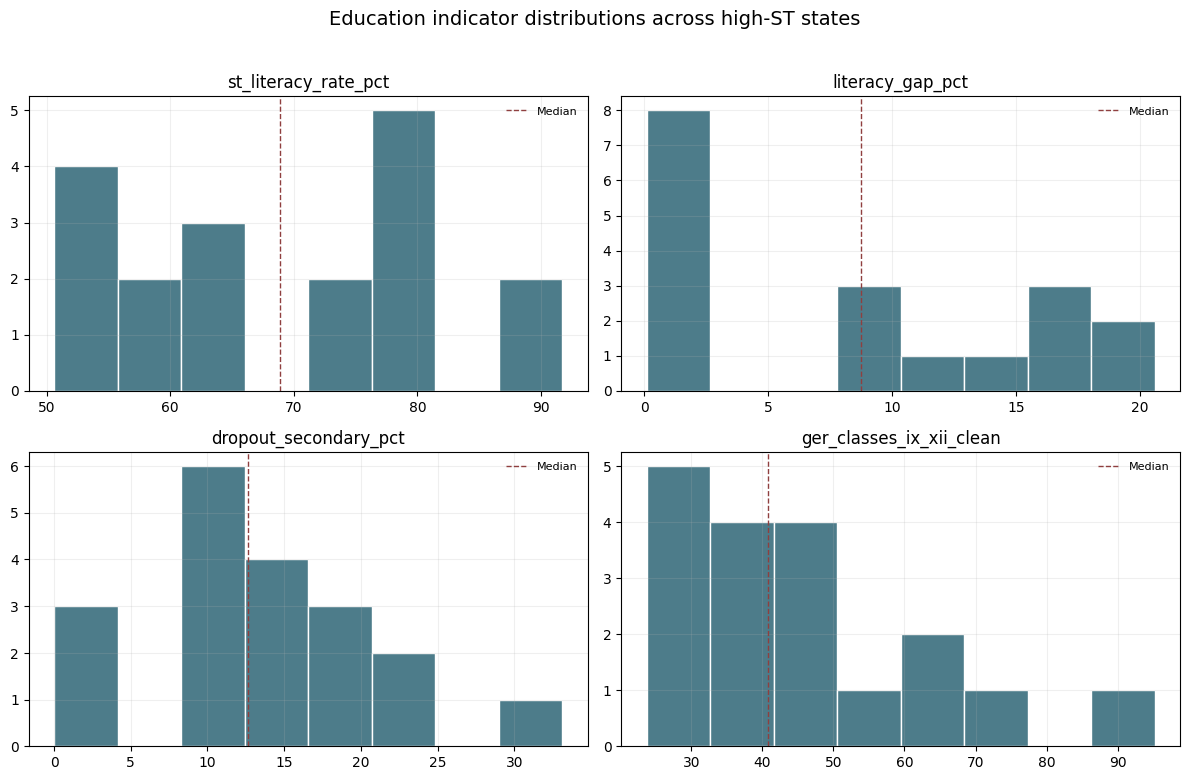

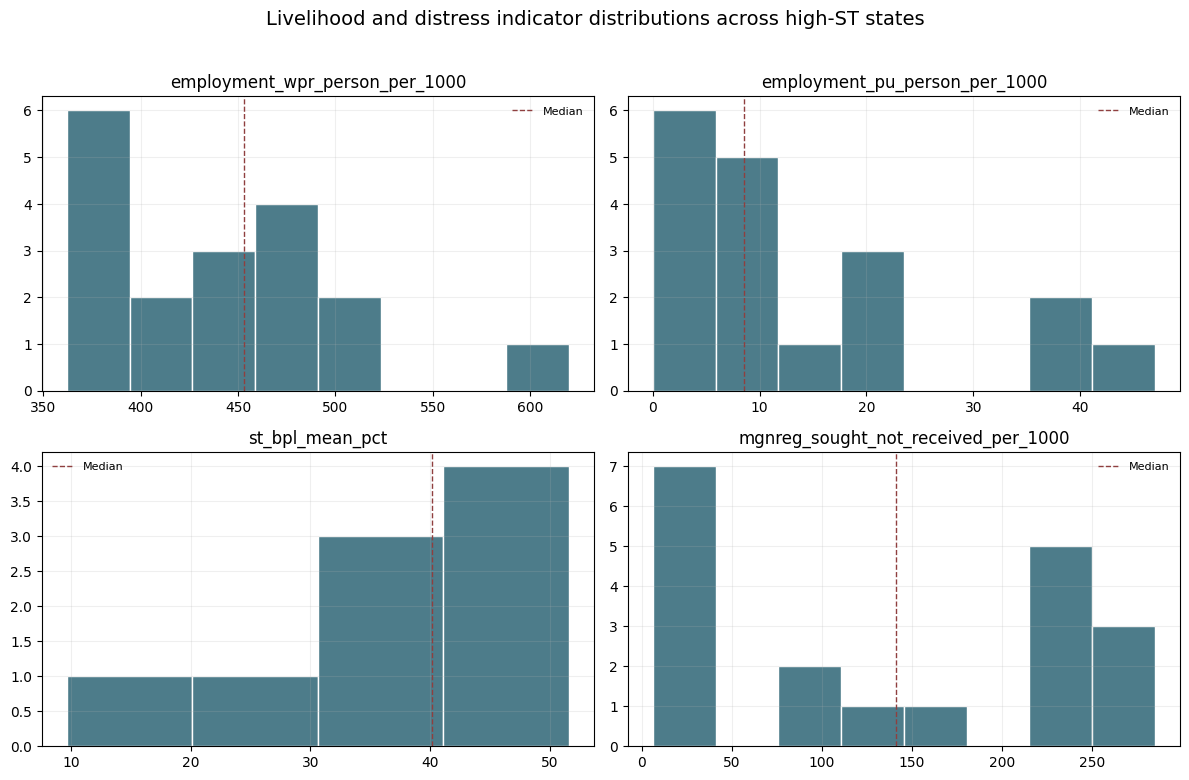

In [8]:
show_distribution_grid(
    high_st,
    ["st_literacy_rate_pct", "literacy_gap_pct", "dropout_secondary_pct", "ger_classes_ix_xii_clean"],
    "Education indicator distributions across high-ST states",
)

show_distribution_grid(
    high_st,
    ["employment_wpr_person_per_1000", "employment_pu_person_per_1000", "st_bpl_mean_pct", "mgnreg_sought_not_received_per_1000"],
    "Livelihood and distress indicator distributions across high-ST states",
)

## Q1. How Do ST Literacy And Literacy Gaps Describe Long-Term Educational Exclusion?

Literacy is not the same as current schooling quality. It mainly tells us whether people have basic reading and writing ability. In this project, literacy is used as a **long-term attainment and exclusion indicator**, while GER and dropout are used as the schooling-pipeline indicators.

In [9]:
q1 = corr_frame(
    high_st,
    ["st_literacy_rate_pct", "literacy_gap_pct"],
    [
        "employment_lfpr_person_per_1000",
        "employment_wpr_person_per_1000",
        "employment_pu_person_per_1000",
        "st_bpl_mean_pct",
    ],
    "high_st_states",
)
q1

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,high_st_states,st_literacy_rate_pct,employment_pu_person_per_1000,18,0.6177,0.0063,0.6177
1,high_st_states,literacy_gap_pct,employment_wpr_person_per_1000,18,0.5387,0.0211,0.5387
2,high_st_states,literacy_gap_pct,employment_pu_person_per_1000,18,-0.4900,0.0390,0.4900
3,high_st_states,literacy_gap_pct,employment_lfpr_person_per_1000,18,0.4853,0.0412,0.4853
4,high_st_states,st_literacy_rate_pct,employment_wpr_person_per_1000,18,-0.4766,0.0455,0.4766
5,high_st_states,st_literacy_rate_pct,employment_lfpr_person_per_1000,18,-0.3873,0.1123,0.3873
6,high_st_states,literacy_gap_pct,st_bpl_mean_pct,9,0.3275,0.3896,0.3275
7,high_st_states,st_literacy_rate_pct,st_bpl_mean_pct,9,-0.0652,0.8676,0.0652


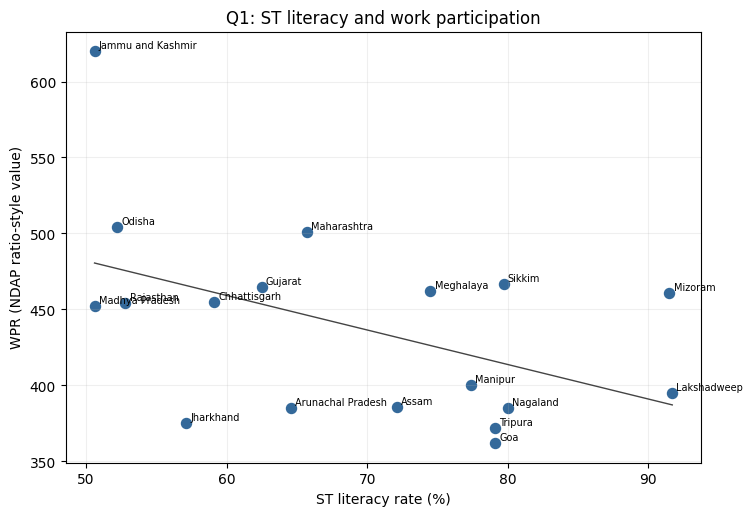

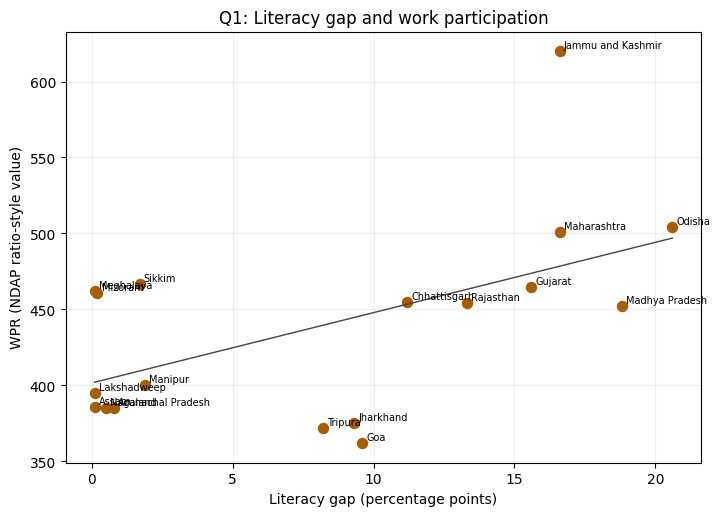

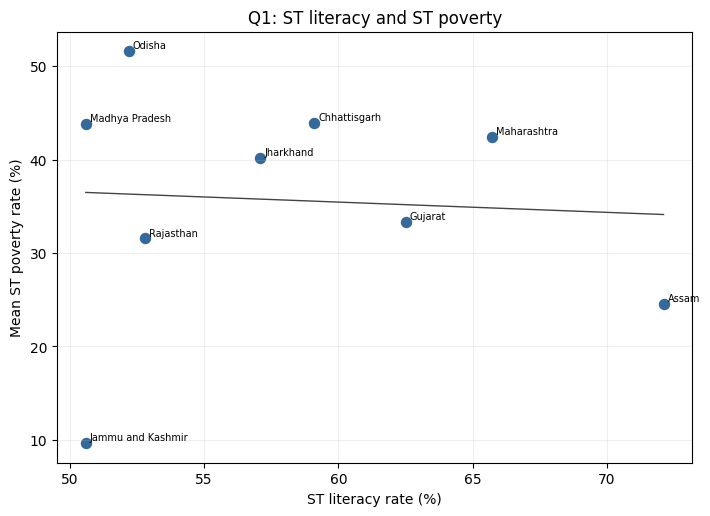

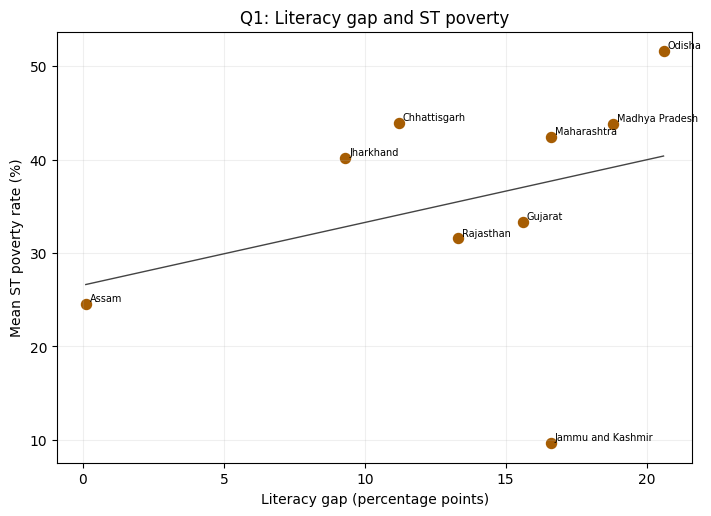

In [10]:
show_scatter(high_st, "st_literacy_rate_pct", "employment_wpr_person_per_1000", "Q1: ST literacy and work participation", "ST literacy rate (%)", "WPR (NDAP ratio-style value)")
show_scatter(high_st, "literacy_gap_pct", "employment_wpr_person_per_1000", "Q1: Literacy gap and work participation", "Literacy gap (percentage points)", "WPR (NDAP ratio-style value)", color="#a65d03")
show_scatter(high_st, "st_literacy_rate_pct", "st_bpl_mean_pct", "Q1: ST literacy and ST poverty", "ST literacy rate (%)", "Mean ST poverty rate (%)")
show_scatter(high_st, "literacy_gap_pct", "st_bpl_mean_pct", "Q1: Literacy gap and ST poverty", "Literacy gap (percentage points)", "Mean ST poverty rate (%)", color="#a65d03")

**Reading Q1:** literacy and the literacy gap are useful for showing long-term exclusion, but they should not be treated as complete measures of educational progress. The current schooling question needs GER and dropout.

## Q2. Do States With Stronger ST Schooling Participation Also Have Lower Dropout And Lower ST Poverty?

This is the more direct schooling question. GER captures participation/enrolment; dropout captures retention; poverty tests whether stronger schooling participation is associated with better economic conditions.

In [11]:
q2 = corr_frame(
    high_st,
    ["ger_classes_i_viii_clean", "ger_classes_ix_xii_clean"],
    ["dropout_primary_pct", "dropout_upper_primary_pct", "dropout_secondary_pct", "st_bpl_mean_pct"],
    "high_st_states",
)
q2

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,high_st_states,ger_classes_i_viii_clean,st_bpl_mean_pct,9,0.7172,0.0296,0.7172
1,high_st_states,ger_classes_ix_xii_clean,dropout_upper_primary_pct,18,-0.5274,0.0245,0.5274
2,high_st_states,ger_classes_ix_xii_clean,dropout_secondary_pct,18,-0.4230,0.0803,0.4230
3,high_st_states,ger_classes_ix_xii_clean,st_bpl_mean_pct,9,0.3540,0.3500,0.3540
4,high_st_states,ger_classes_i_viii_clean,dropout_primary_pct,18,0.2788,0.2626,0.2788
5,high_st_states,ger_classes_ix_xii_clean,dropout_primary_pct,18,-0.2406,0.3362,0.2406
6,high_st_states,ger_classes_i_viii_clean,dropout_upper_primary_pct,18,-0.1178,0.6416,0.1178
7,high_st_states,ger_classes_i_viii_clean,dropout_secondary_pct,18,-0.0795,0.7538,0.0795


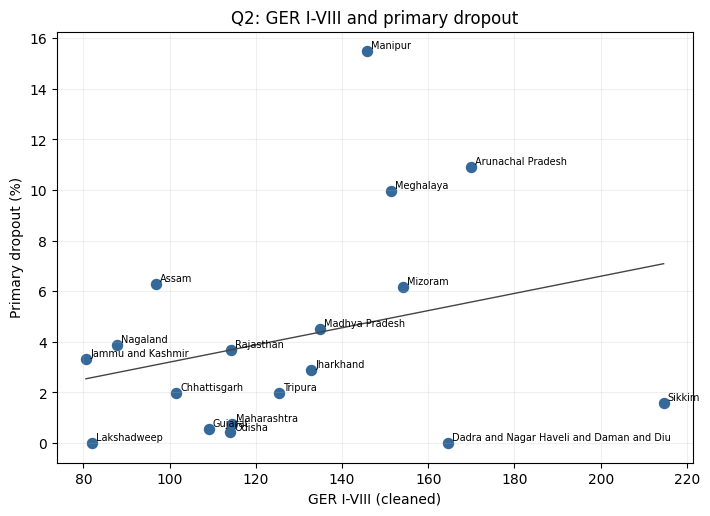

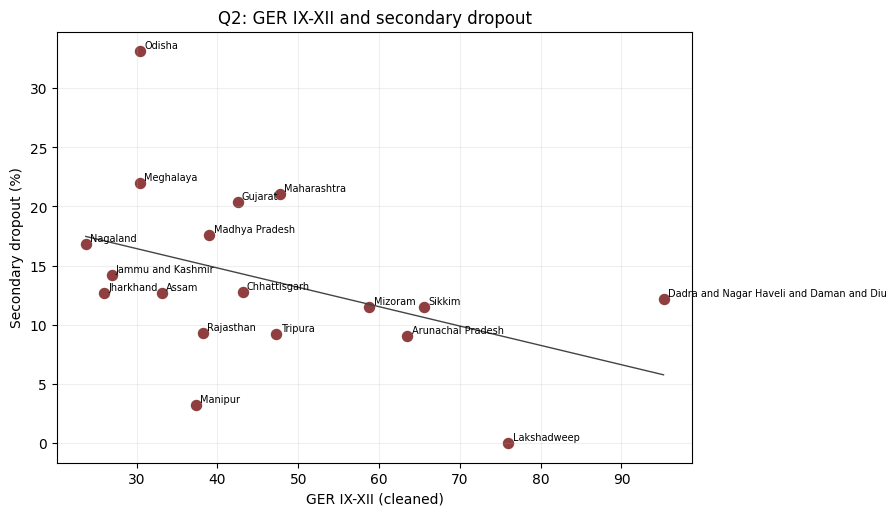

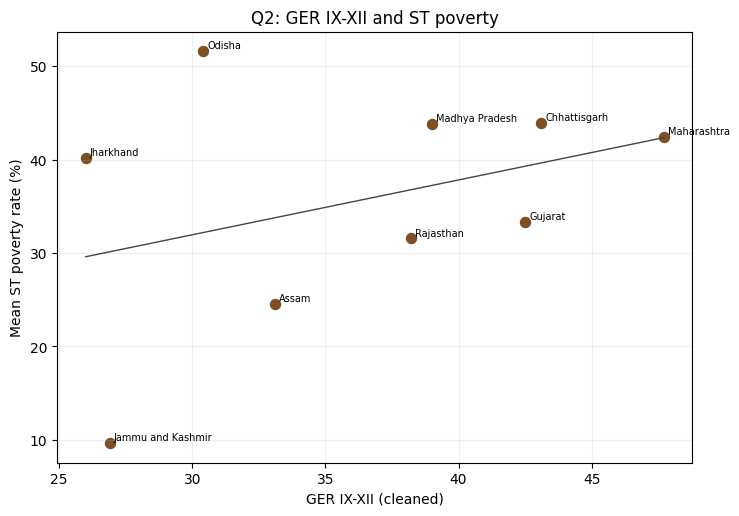

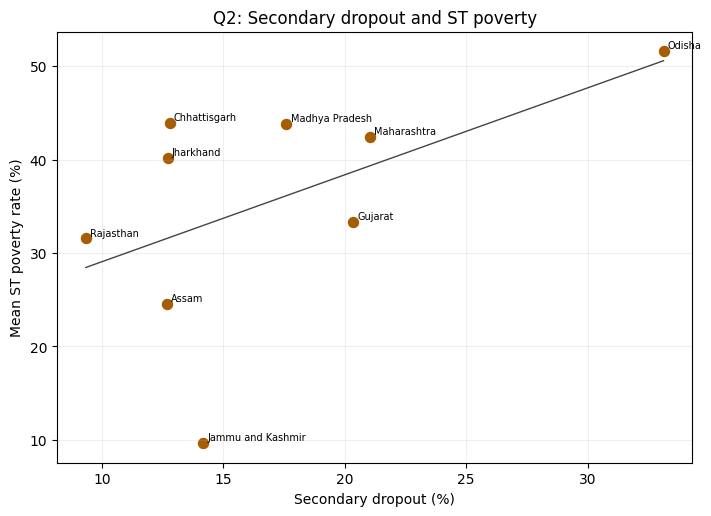

In [12]:
show_scatter(high_st, "ger_classes_i_viii_clean", "dropout_primary_pct", "Q2: GER I-VIII and primary dropout", "GER I-VIII (cleaned)", "Primary dropout (%)")
show_scatter(high_st, "ger_classes_ix_xii_clean", "dropout_secondary_pct", "Q2: GER IX-XII and secondary dropout", "GER IX-XII (cleaned)", "Secondary dropout (%)", color="#8f3f3f")
show_scatter(high_st, "ger_classes_ix_xii_clean", "st_bpl_mean_pct", "Q2: GER IX-XII and ST poverty", "GER IX-XII (cleaned)", "Mean ST poverty rate (%)", color="#7f4f24")
show_scatter(high_st, "dropout_secondary_pct", "st_bpl_mean_pct", "Q2: Secondary dropout and ST poverty", "Secondary dropout (%)", "Mean ST poverty rate (%)", color="#a65d03")

In [13]:
high_dropout_high_poverty = high_st[
    high_st["dropout_secondary_pct"].notna() & high_st["st_bpl_mean_pct"].notna()
][[
    "state",
    "ger_classes_ix_xii_clean",
    "dropout_secondary_pct",
    "st_bpl_mean_pct",
    "employment_wpr_person_per_1000",
    "mgnreg_sought_not_received_per_1000",
]].sort_values(["dropout_secondary_pct", "st_bpl_mean_pct"], ascending=[False, False])

high_dropout_high_poverty

,state,ger_classes_ix_xii_clean,dropout_secondary_pct,st_bpl_mean_pct,employment_wpr_person_per_1000,mgnreg_sought_not_received_per_1000
0,Odisha,30.4,33.12,51.60,504.0,255
3,Maharashtra,47.7,21.04,42.45,501.0,218
8,Gujarat,42.5,20.35,33.30,465.0,96
1,Madhya Pradesh,39.0,17.60,43.80,452.0,236
7,Jammu and Kashmir,26.9,14.17,9.65,620.0,32
6,Chhattisgarh,43.1,12.79,43.90,455.0,233
2,Jharkhand,26.0,12.71,40.15,375.0,245
11,Assam,33.1,12.67,24.50,386.0,282
4,Rajasthan,38.2,9.34,31.55,454.0,82


**Reading Q2:** this is stronger than using literacy alone. If GER is high but dropout or poverty is also high, schooling access is not translating into stable progression or economic security.

## Q3. Are Enrolment And GER Enough To Indicate Educational Progress, Or Do Dropout Rates Tell A Different Story?

In [14]:
q2 = corr_frame(
    high_st,
    ["ger_classes_i_viii_clean", "ger_classes_ix_xii_clean", "primary_total"],
    ["dropout_secondary_pct", "employment_wpr_person_per_1000", "st_bpl_mean_pct"],
    "high_st_states",
)
q2

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,high_st_states,ger_classes_i_viii_clean,st_bpl_mean_pct,9,0.7172,0.0296,0.7172
1,high_st_states,primary_total,st_bpl_mean_pct,9,0.6833,0.0425,0.6833
2,high_st_states,primary_total,dropout_secondary_pct,19,0.5008,0.0290,0.5008
3,high_st_states,ger_classes_ix_xii_clean,dropout_secondary_pct,18,-0.4230,0.0803,0.4230
4,high_st_states,ger_classes_ix_xii_clean,st_bpl_mean_pct,9,0.3540,0.3500,0.3540
5,high_st_states,primary_total,employment_wpr_person_per_1000,18,0.1855,0.4612,0.1855
6,high_st_states,ger_classes_ix_xii_clean,employment_wpr_person_per_1000,17,-0.1843,0.4789,0.1843
7,high_st_states,ger_classes_i_viii_clean,employment_wpr_person_per_1000,17,-0.1373,0.5992,0.1373
8,high_st_states,ger_classes_i_viii_clean,dropout_secondary_pct,18,-0.0795,0.7538,0.0795


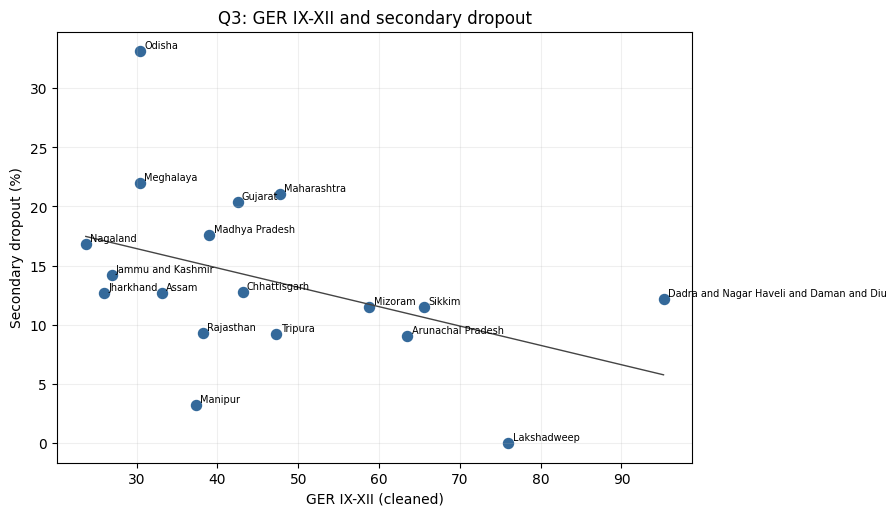

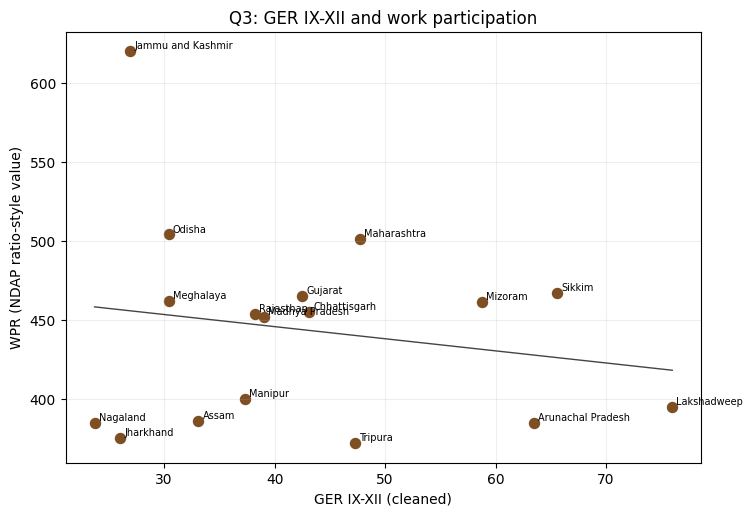

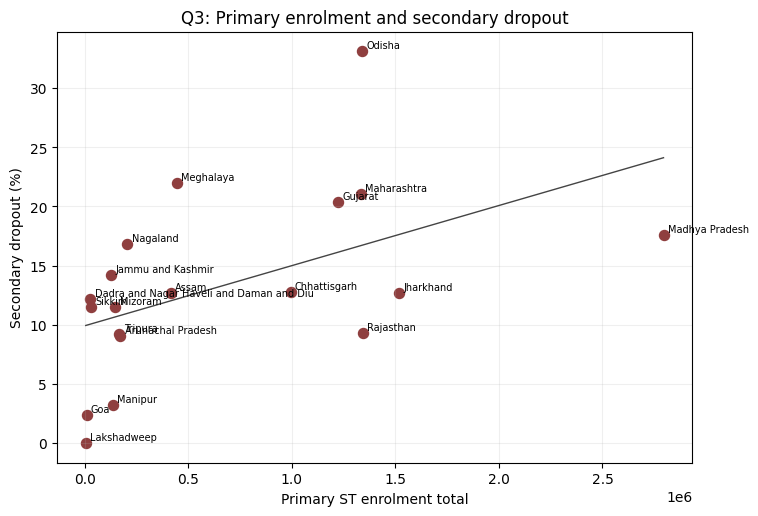

In [15]:
show_scatter(high_st, "ger_classes_ix_xii_clean", "dropout_secondary_pct", "Q3: GER IX-XII and secondary dropout", "GER IX-XII (cleaned)", "Secondary dropout (%)")
show_scatter(high_st, "ger_classes_ix_xii_clean", "employment_wpr_person_per_1000", "Q3: GER IX-XII and work participation", "GER IX-XII (cleaned)", "WPR (NDAP ratio-style value)", color="#7f4f24")
show_scatter(high_st, "primary_total", "dropout_secondary_pct", "Q3: Primary enrolment and secondary dropout", "Primary ST enrolment total", "Secondary dropout (%)", color="#8f3f3f")

In [16]:
med_ger = high_st["ger_classes_ix_xii_clean"].median()
med_dropout = high_st["dropout_secondary_pct"].median()
med_wpr = high_st["employment_wpr_person_per_1000"].median()

high_ger_high_dropout = high_st[
    (high_st["ger_classes_ix_xii_clean"] >= med_ger)
    & (high_st["dropout_secondary_pct"] >= med_dropout)
][["state", "ger_classes_ix_xii_clean", "dropout_secondary_pct", "employment_wpr_person_per_1000", "st_bpl_mean_pct"]].sort_values(["dropout_secondary_pct", "ger_classes_ix_xii_clean"], ascending=[False, False])

high_ger_low_wpr = high_st[
    (high_st["ger_classes_ix_xii_clean"] >= med_ger)
    & (high_st["employment_wpr_person_per_1000"] <= med_wpr)
][["state", "ger_classes_ix_xii_clean", "dropout_secondary_pct", "employment_wpr_person_per_1000", "st_bpl_mean_pct"]].sort_values("employment_wpr_person_per_1000")

display(Markdown("### States with relatively high GER IX-XII but also high dropout"))
display(high_ger_high_dropout)
display(Markdown("### States with relatively high GER IX-XII but weak work participation"))
display(high_ger_low_wpr)

### States with relatively high GER IX-XII but also high dropout

,state,ger_classes_ix_xii_clean,dropout_secondary_pct,employment_wpr_person_per_1000,st_bpl_mean_pct
3,Maharashtra,47.7,21.04,501.0,42.45
8,Gujarat,42.5,20.35,465.0,33.30
6,Chhattisgarh,43.1,12.79,455.0,43.90


### States with relatively high GER IX-XII but weak work participation

,state,ger_classes_ix_xii_clean,dropout_secondary_pct,employment_wpr_person_per_1000,st_bpl_mean_pct
9,Tripura,47.3,9.21,372.0,NaN
12,Arunachal Pradesh,63.5,9.04,385.0,NaN
16,Lakshadweep,76.0,0.00,395.0,NaN


**Reading Q3:** access-style indicators are not enough. Some states show reasonable GER but still struggle with retention or weak work participation.

## Q4. Is The Literacy Gap More Informative Than ST Literacy Alone In Explaining Disadvantage?

In [17]:
q3 = compare_predictors(
    high_st,
    ["st_literacy_rate_pct", "literacy_gap_pct"],
    ["st_bpl_mean_pct", "employment_wpr_person_per_1000", "employment_pu_person_per_1000", "dropout_secondary_pct"],
)
q3

,outcome,stronger_predictor,n,pearson_r,pearson_p,runner_up,runner_up_abs_r
0,st_bpl_mean_pct,literacy_gap_pct,9,0.3275,0.3896,st_literacy_rate_pct,0.0652
1,employment_wpr_person_per_1000,literacy_gap_pct,18,0.5387,0.0211,st_literacy_rate_pct,0.4766
2,employment_pu_person_per_1000,st_literacy_rate_pct,18,0.6177,0.0063,literacy_gap_pct,0.4900
3,dropout_secondary_pct,literacy_gap_pct,18,0.5099,0.0306,st_literacy_rate_pct,0.5051


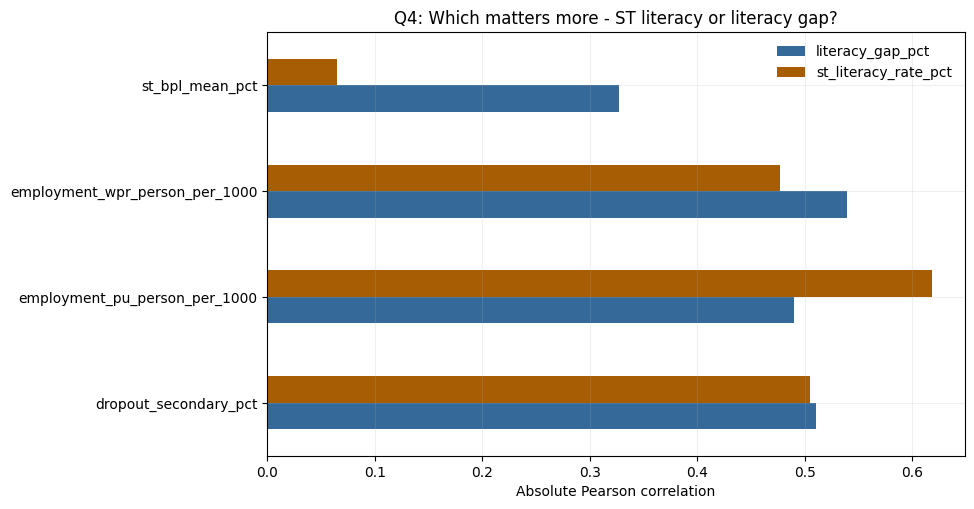

In [18]:
show_abs_correlation_compare(
    high_st,
    ["st_literacy_rate_pct", "literacy_gap_pct"],
    ["st_bpl_mean_pct", "employment_wpr_person_per_1000", "employment_pu_person_per_1000", "dropout_secondary_pct"],
    "Q4: Which matters more - ST literacy or literacy gap?",
)

**Reading Q4:** the literacy gap is often at least as informative as absolute ST literacy, especially for work participation, unemployment, and dropout. It captures exclusion, not just low level.

## Q5. Are There States Where Educational Indicators Look Reasonable, But Employment Or Poverty Outcomes Remain Weak?

We label these as **states with an education-livelihood mismatch**.

In [19]:
med_lit = high_st["st_literacy_rate_pct"].median()
med_ger = high_st["ger_classes_ix_xii_clean"].median()
med_wpr = high_st["employment_wpr_person_per_1000"].median()
med_unemp = high_st["employment_pu_person_per_1000"].median()
med_pov = high_st["st_bpl_mean_pct"].median()
med_mgnreg = high_st["mgnreg_sought_not_received_per_1000"].median()

mismatch_rows = []
for _, row in high_st.iterrows():
    education_ok = (
        (pd.notna(row["st_literacy_rate_pct"]) and row["st_literacy_rate_pct"] >= med_lit)
        or (pd.notna(row["ger_classes_ix_xii_clean"]) and row["ger_classes_ix_xii_clean"] >= med_ger)
    )
    distress = []
    if pd.notna(row["employment_wpr_person_per_1000"]) and row["employment_wpr_person_per_1000"] <= med_wpr:
        distress.append("low_wpr")
    if pd.notna(row["employment_pu_person_per_1000"]) and row["employment_pu_person_per_1000"] >= med_unemp:
        distress.append("high_unemployment")
    if pd.notna(row["st_bpl_mean_pct"]) and row["st_bpl_mean_pct"] >= med_pov:
        distress.append("high_poverty")
    if pd.notna(row["mgnreg_sought_not_received_per_1000"]) and row["mgnreg_sought_not_received_per_1000"] >= med_mgnreg:
        distress.append("high_mgnreg_unmet")

    if education_ok and len(distress) >= 2:
        mismatch_rows.append(
            {
                "state": row["state"],
                "st_literacy_rate_pct": row["st_literacy_rate_pct"],
                "ger_ix_xii": row["ger_classes_ix_xii_clean"],
                "employment_wpr_person_per_1000": row["employment_wpr_person_per_1000"],
                "employment_pu_person_per_1000": row["employment_pu_person_per_1000"],
                "st_bpl_mean_pct": row["st_bpl_mean_pct"],
                "mgnreg_sought_not_received_per_1000": row["mgnreg_sought_not_received_per_1000"],
                "distress_count": len(distress),
                "distress_flags": ", ".join(distress),
            }
        )

mismatch_df = pd.DataFrame(mismatch_rows).sort_values(["distress_count", "state"], ascending=[False, True])
mismatch_df

,state,st_literacy_rate_pct,ger_ix_xii,employment_wpr_person_per_1000,employment_pu_person_per_1000,st_bpl_mean_pct,mgnreg_sought_not_received_per_1000,distress_count,distress_flags
4,Assam,72.1,33.1,386.0,18.0,24.50,282,3,"low_wpr, high_unemployment, high_mgnreg_unmet"
1,Nagaland,80.0,23.7,385.0,47.0,NaN,154,3,"low_wpr, high_unemployment, high_mgnreg_unmet"
5,Arunachal Pradesh,64.6,63.5,385.0,7.0,NaN,285,2,"low_wpr, high_mgnreg_unmet"
2,Chhattisgarh,59.1,43.1,455.0,0.0,43.90,233,2,"high_poverty, high_mgnreg_unmet"
6,Goa,79.1,NaN,362.0,15.0,NaN,6,2,"low_wpr, high_unemployment"
7,Lakshadweep,91.7,76.0,395.0,38.0,NaN,21,2,"low_wpr, high_unemployment"
0,Maharashtra,65.7,47.7,501.0,4.0,42.45,218,2,"high_poverty, high_mgnreg_unmet"
8,Manipur,77.4,37.3,400.0,10.0,NaN,9,2,"low_wpr, high_unemployment"
3,Tripura,79.1,47.3,372.0,38.0,NaN,39,2,"low_wpr, high_unemployment"


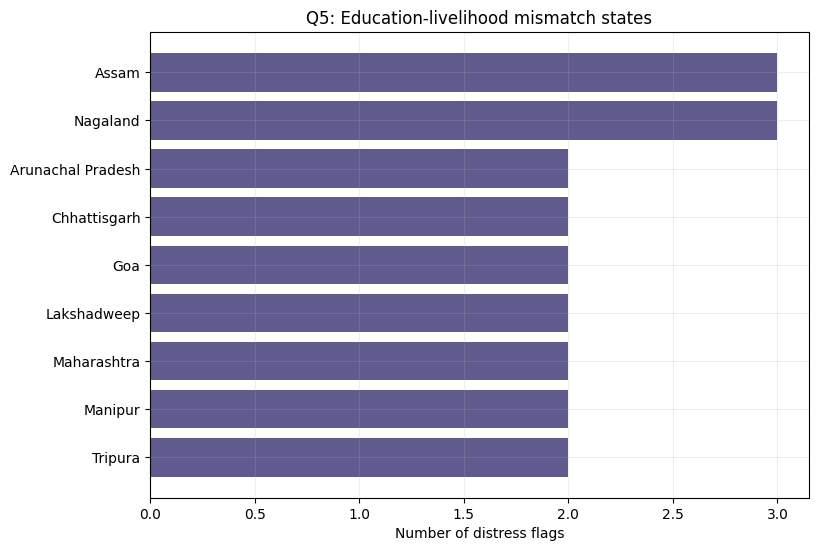

In [20]:
if not mismatch_df.empty:
    fig, ax = plt.subplots(figsize=(8.5, 0.45 * len(mismatch_df) + 2))
    ax.barh(mismatch_df["state"], mismatch_df["distress_count"], color="#5f5b8f")
    ax.invert_yaxis()
    ax.set_title("Q5: Education-livelihood mismatch states")
    ax.set_xlabel("Number of distress flags")
    plt.show()

**Reading Q5:** this is one of the most policy-useful outputs. These states do not fit a simple low-education-equals-bad-outcomes story.

## Q6. Does MGNREG Unmet Demand Reflect Deeper Livelihood Distress Among ST Households?

In [21]:
q5 = corr_frame(
    high_st,
    ["mgnreg_sought_not_received_per_1000", "mgnreg_average_days_worked", "mgnreg_job_card_households_per_1000"],
    ["st_bpl_mean_pct", "dropout_secondary_pct", "employment_wpr_person_per_1000", "st_literacy_rate_pct"],
    "high_st_states",
)
q5

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,high_st_states,mgnreg_sought_not_received_per_1000,st_bpl_mean_pct,9,0.6488,0.0587,0.6488
1,high_st_states,mgnreg_sought_not_received_per_1000,st_literacy_rate_pct,18,-0.5271,0.0246,0.5271
2,high_st_states,mgnreg_sought_not_received_per_1000,dropout_secondary_pct,19,0.5114,0.0252,0.5114
3,high_st_states,mgnreg_average_days_worked,st_literacy_rate_pct,18,0.4089,0.0920,0.4089
4,high_st_states,mgnreg_average_days_worked,dropout_secondary_pct,19,-0.2808,0.2442,0.2808
5,high_st_states,mgnreg_job_card_households_per_1000,st_bpl_mean_pct,9,0.2401,0.5337,0.2401
6,high_st_states,mgnreg_average_days_worked,employment_wpr_person_per_1000,18,-0.1521,0.5469,0.1521
7,high_st_states,mgnreg_job_card_households_per_1000,st_literacy_rate_pct,18,0.1448,0.5664,0.1448
8,high_st_states,mgnreg_average_days_worked,st_bpl_mean_pct,9,0.0802,0.8375,0.0802
9,high_st_states,mgnreg_sought_not_received_per_1000,employment_wpr_person_per_1000,18,-0.0677,0.7895,0.0677


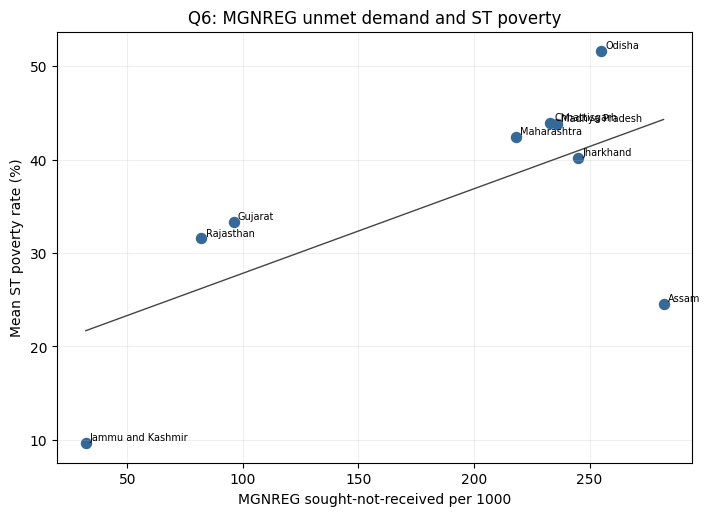

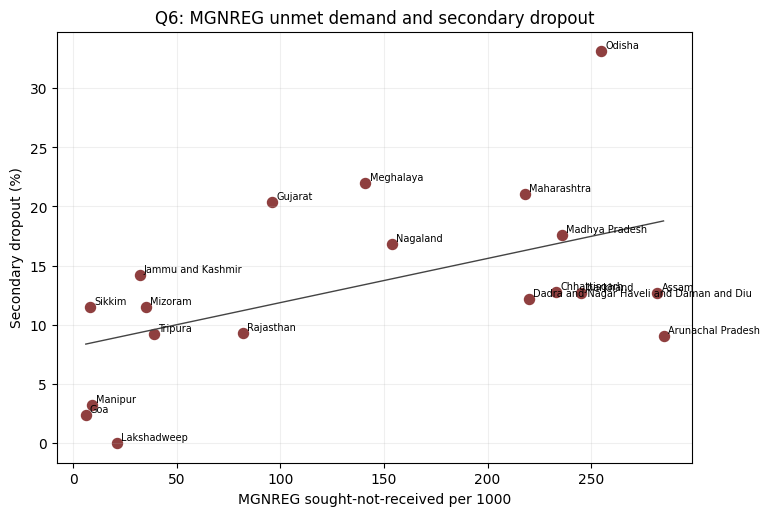

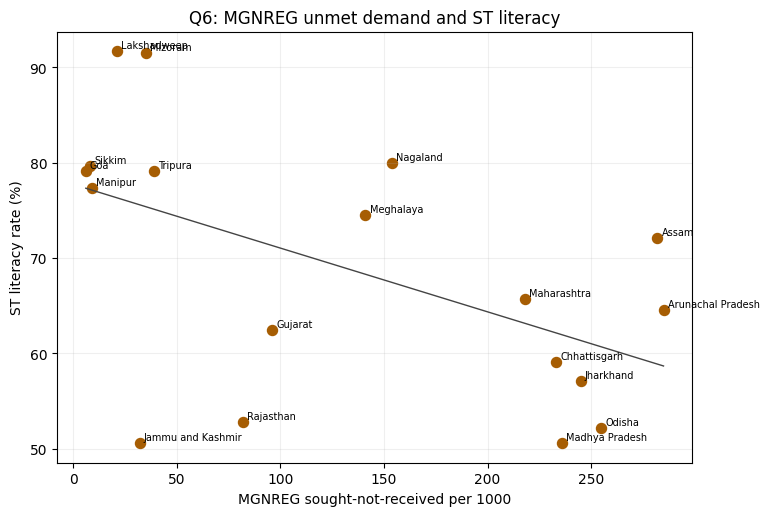

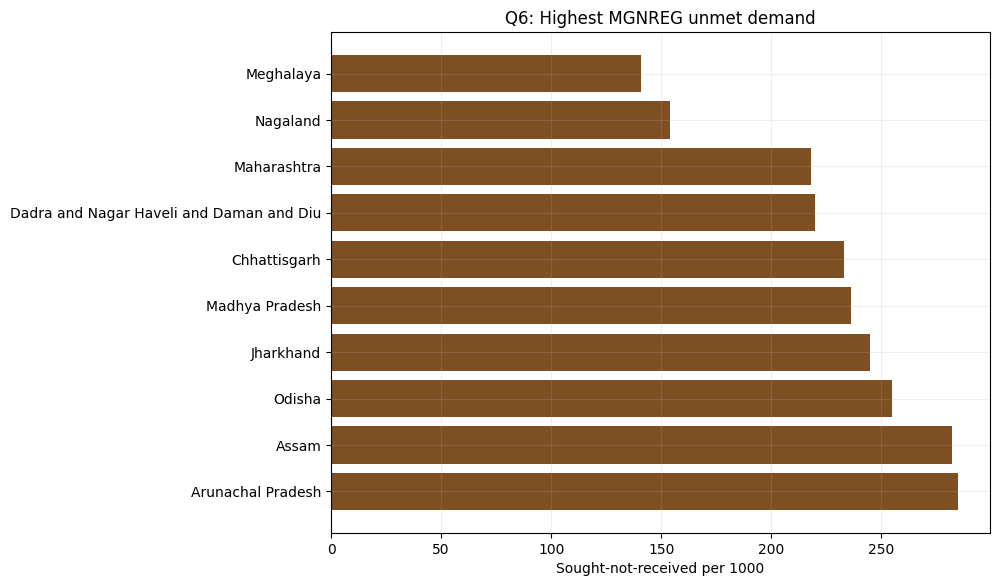

In [22]:
show_scatter(high_st, "mgnreg_sought_not_received_per_1000", "st_bpl_mean_pct", "Q6: MGNREG unmet demand and ST poverty", "MGNREG sought-not-received per 1000", "Mean ST poverty rate (%)")
show_scatter(high_st, "mgnreg_sought_not_received_per_1000", "dropout_secondary_pct", "Q6: MGNREG unmet demand and secondary dropout", "MGNREG sought-not-received per 1000", "Secondary dropout (%)", color="#8f3f3f")
show_scatter(high_st, "mgnreg_sought_not_received_per_1000", "st_literacy_rate_pct", "Q6: MGNREG unmet demand and ST literacy", "MGNREG sought-not-received per 1000", "ST literacy rate (%)", color="#a65d03")
show_rank_bar(high_st, "mgnreg_sought_not_received_per_1000", "Q6: Highest MGNREG unmet demand", "Sought-not-received per 1000", ascending=False, top_n=10, color="#7f4f24")

**Reading Q6:** unmet MGNREG demand behaves like a distress indicator more clearly than simple job-card counts do.

## Q7. Does Secondary Dropout Appear To Be A Stronger Warning Signal Of Poverty And Weak Labour Outcomes Than Literacy Alone?

In [23]:
q6 = compare_predictors(
    high_st,
    ["st_literacy_rate_pct", "dropout_secondary_pct"],
    ["st_bpl_mean_pct", "employment_wpr_person_per_1000", "employment_pu_person_per_1000", "mgnreg_sought_not_received_per_1000"],
)
q6

,outcome,stronger_predictor,n,pearson_r,pearson_p,runner_up,runner_up_abs_r
0,st_bpl_mean_pct,dropout_secondary_pct,9,0.5266,0.1453,st_literacy_rate_pct,0.0652
1,employment_wpr_person_per_1000,dropout_secondary_pct,18,0.5091,0.0309,st_literacy_rate_pct,0.4766
2,employment_pu_person_per_1000,st_literacy_rate_pct,18,0.6177,0.0063,dropout_secondary_pct,0.3165
3,mgnreg_sought_not_received_per_1000,st_literacy_rate_pct,18,-0.5271,0.0246,dropout_secondary_pct,0.5114


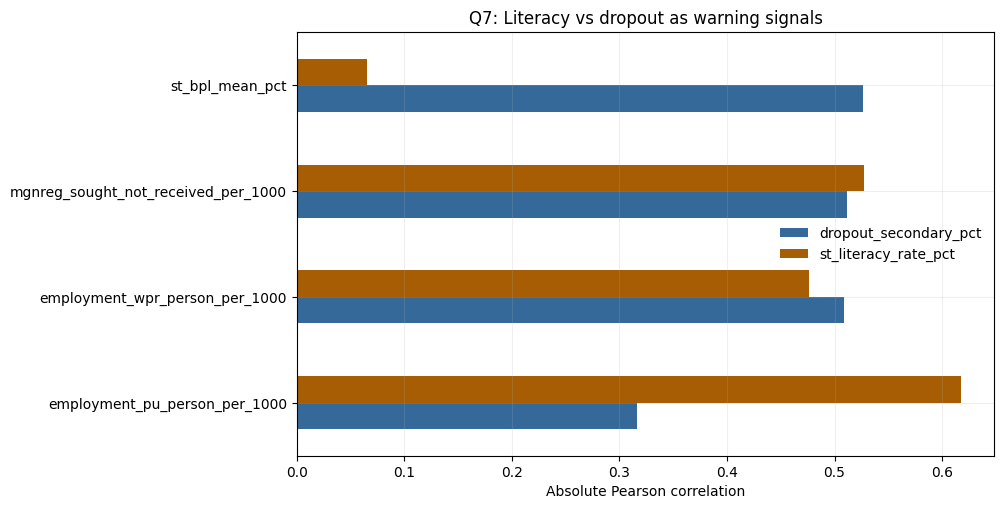

In [24]:
show_abs_correlation_compare(
    high_st,
    ["st_literacy_rate_pct", "dropout_secondary_pct"],
    ["st_bpl_mean_pct", "employment_wpr_person_per_1000", "employment_pu_person_per_1000", "mgnreg_sought_not_received_per_1000"],
    "Q7: Literacy vs dropout as warning signals",
)

**Reading Q7:** secondary dropout is often the stronger warning signal for poverty, weak work participation, and MGNREG distress.

## Q8. Do High-ST-Share States Systematically Perform Worse, Or Do Outcomes Vary Substantially?

In [25]:
q7 = corr_frame(
    all_states,
    ["st_share_state_population_pct"],
    ["st_literacy_rate_pct", "dropout_secondary_pct", "st_bpl_mean_pct", "employment_wpr_person_per_1000"],
    "all_states",
)
q7

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,all_states,st_share_state_population_pct,st_literacy_rate_pct,27,0.6014,0.0009,0.6014
1,all_states,st_share_state_population_pct,st_bpl_mean_pct,18,0.5531,0.0173,0.5531
2,all_states,st_share_state_population_pct,dropout_secondary_pct,30,0.0842,0.6582,0.0842
3,all_states,st_share_state_population_pct,employment_wpr_person_per_1000,30,-0.0644,0.7352,0.0644


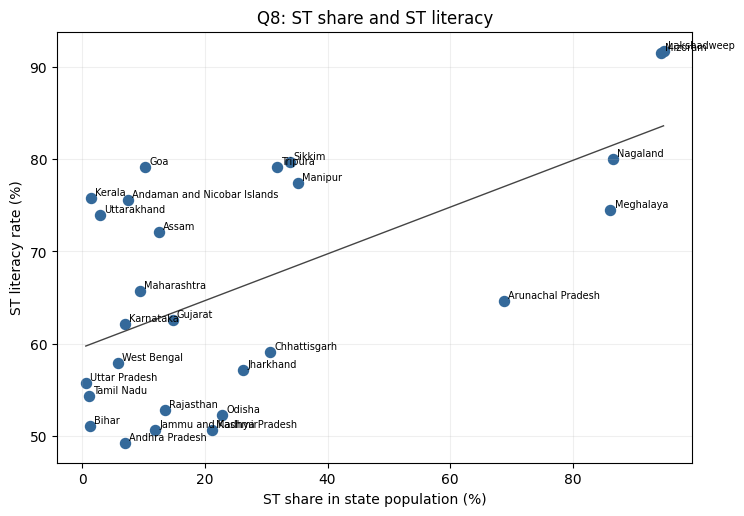

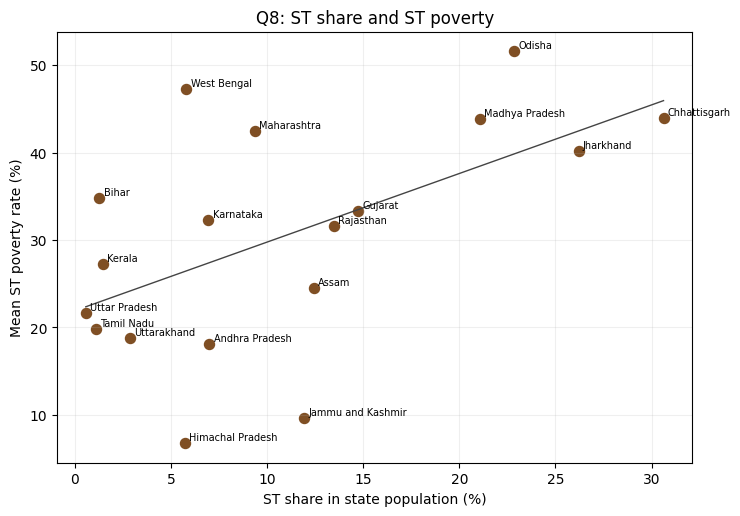

In [26]:
show_scatter(all_states, "st_share_state_population_pct", "st_literacy_rate_pct", "Q8: ST share and ST literacy", "ST share in state population (%)", "ST literacy rate (%)")
show_scatter(all_states, "st_share_state_population_pct", "st_bpl_mean_pct", "Q8: ST share and ST poverty", "ST share in state population (%)", "Mean ST poverty rate (%)", color="#7f4f24")

**Reading Q8:** concentration alone does not explain everything. High-ST states differ sharply in education and livelihood outcomes.

## Q9. Do States With High Concentrations Of ST Villages Show Different Education And Livelihood Outcomes?

Raw village counts are not directly comparable across states, so the notebook uses villages per 100,000 ST population.

In [27]:
q8 = corr_frame(
    high_st,
    ["villages_gt50_per_100k_st_pop"],
    ["st_literacy_rate_pct", "dropout_secondary_pct", "st_bpl_mean_pct", "mgnreg_sought_not_received_per_1000"],
    "high_st_states",
)
q8

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,high_st_states,villages_gt50_per_100k_st_pop,mgnreg_sought_not_received_per_1000,18,0.5025,0.0335,0.5025
1,high_st_states,villages_gt50_per_100k_st_pop,st_bpl_mean_pct,8,0.4109,0.3119,0.4109
2,high_st_states,villages_gt50_per_100k_st_pop,st_literacy_rate_pct,17,-0.1993,0.4432,0.1993
3,high_st_states,villages_gt50_per_100k_st_pop,dropout_secondary_pct,18,0.1257,0.6192,0.1257


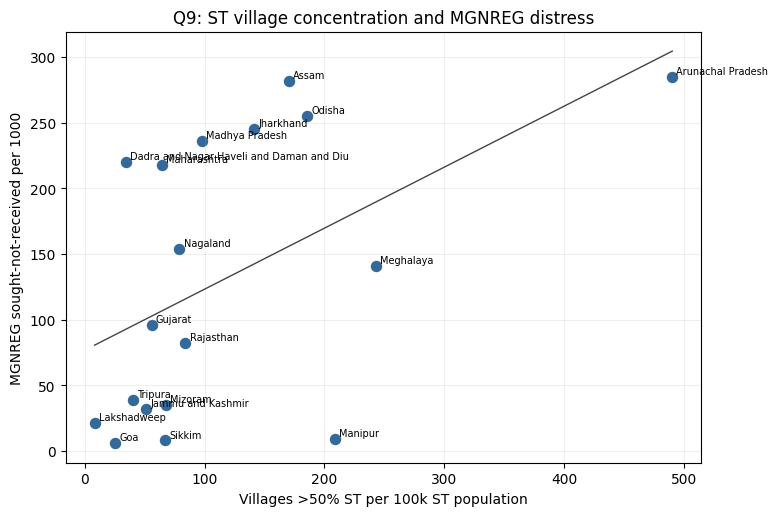

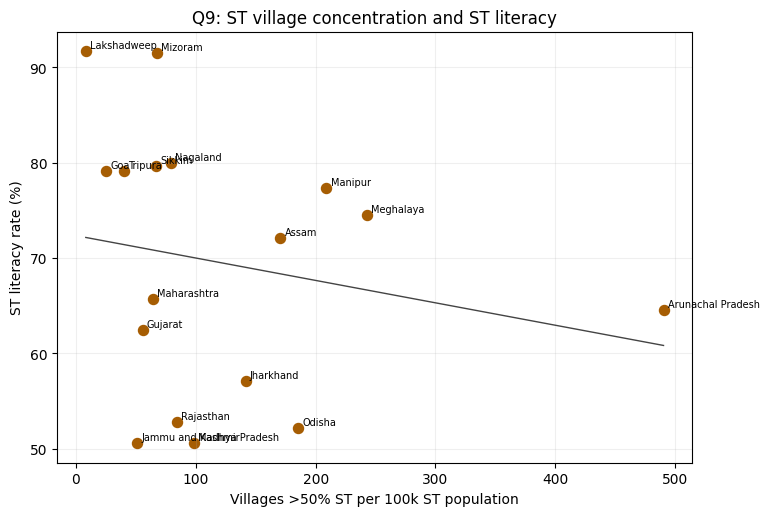

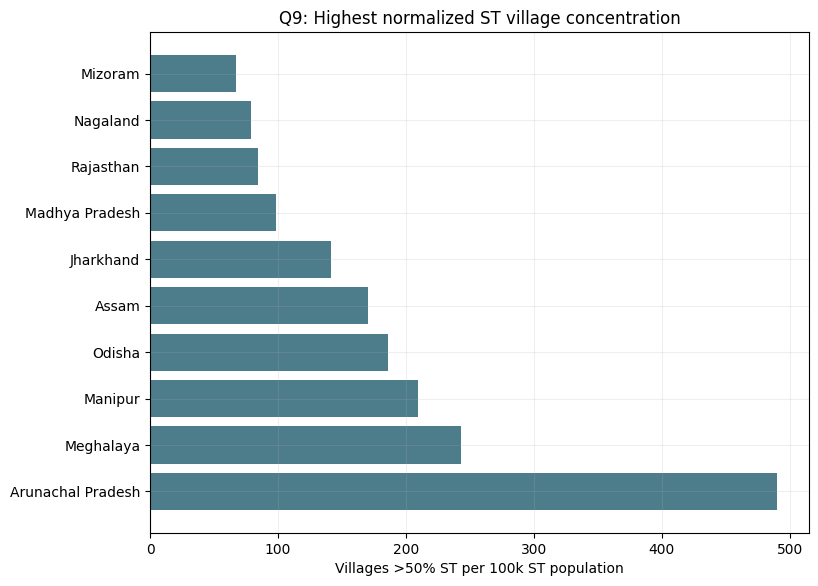

In [28]:
show_scatter(high_st, "villages_gt50_per_100k_st_pop", "mgnreg_sought_not_received_per_1000", "Q9: ST village concentration and MGNREG distress", "Villages >50% ST per 100k ST population", "MGNREG sought-not-received per 1000")
show_scatter(high_st, "villages_gt50_per_100k_st_pop", "st_literacy_rate_pct", "Q9: ST village concentration and ST literacy", "Villages >50% ST per 100k ST population", "ST literacy rate (%)", color="#a65d03")
show_rank_bar(high_st, "villages_gt50_per_100k_st_pop", "Q9: Highest normalized ST village concentration", "Villages >50% ST per 100k ST population", ascending=False, top_n=10, color="#4d7c8a")

**Reading Q9:** normalized village concentration looks more connected to MGNREG distress than to literacy alone. It is useful, but secondary.

## Q10. Are There Gender-Specific Disadvantages Hidden Behind State Averages?

In [29]:
q9 = corr_frame(
    high_st,
    ["female_literacy_gap_pct", "tribe_weighted_literacy_female_pct"],
    ["employment_wpr_female_per_1000", "st_bpl_mean_pct", "low_literacy_district_count"],
    "high_st_states",
)
q9

,sample,x,y,n,pearson_r,pearson_p,abs_r
0,high_st_states,tribe_weighted_literacy_female_pct,low_literacy_district_count,7,-0.8764,0.0096,0.8764
1,high_st_states,tribe_weighted_literacy_female_pct,employment_wpr_female_per_1000,18,-0.4623,0.0534,0.4623
2,high_st_states,female_literacy_gap_pct,employment_wpr_female_per_1000,18,0.3054,0.2178,0.3054
3,high_st_states,female_literacy_gap_pct,low_literacy_district_count,7,0.2710,0.5566,0.2710
4,high_st_states,female_literacy_gap_pct,st_bpl_mean_pct,9,0.0504,0.8975,0.0504
5,high_st_states,tribe_weighted_literacy_female_pct,st_bpl_mean_pct,9,-0.0382,0.9222,0.0382


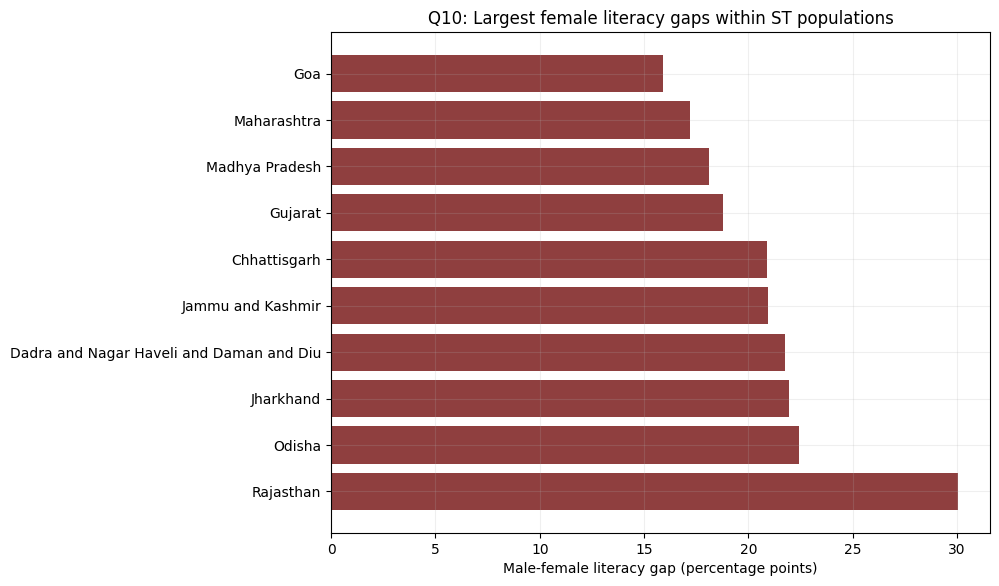

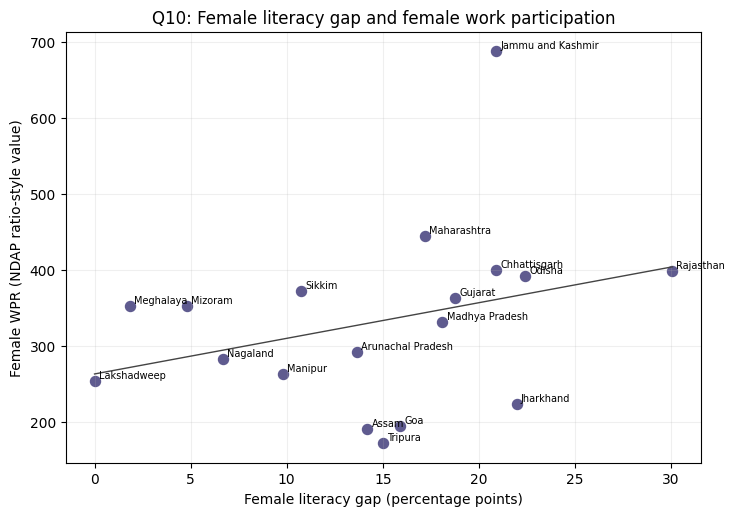

In [30]:
show_rank_bar(high_st, "female_literacy_gap_pct", "Q10: Largest female literacy gaps within ST populations", "Male-female literacy gap (percentage points)", ascending=False, top_n=10, color="#8f3f3f")
show_scatter(high_st, "female_literacy_gap_pct", "employment_wpr_female_per_1000", "Q10: Female literacy gap and female work participation", "Female literacy gap (percentage points)", "Female WPR (NDAP ratio-style value)", color="#5f5b8f")

In [31]:
high_st[[
    "state",
    "tribe_weighted_literacy_male_pct",
    "tribe_weighted_literacy_female_pct",
    "female_literacy_gap_pct",
    "low_literacy_district_count",
    "employment_wpr_female_per_1000",
]].sort_values("female_literacy_gap_pct", ascending=False).head(10)

,state,tribe_weighted_literacy_male_pct,tribe_weighted_literacy_female_pct,female_literacy_gap_pct,low_literacy_district_count,employment_wpr_female_per_1000
4,Rajasthan,67.200036,37.133955,30.066081,11.0,399.0
0,Odisha,63.441680,41.039995,22.401685,6.0,392.0
2,Jharkhand,68.123978,46.163515,21.960463,6.0,223.0
10,Dadra and Nagar Haveli and Daman and Diu,78.700355,56.934504,21.765852,NaN,NaN
7,Jammu and Kashmir,60.082673,39.166195,20.916478,15.0,688.0
6,Chhattisgarh,69.525111,48.615475,20.909635,2.0,400.0
8,Gujarat,71.448346,52.678112,18.770234,1.0,363.0
1,Madhya Pradesh,59.296080,41.195279,18.100800,11.0,332.0
3,Maharashtra,73.863914,56.660439,17.203475,NaN,445.0
15,Goa,87.191510,71.292866,15.898644,NaN,195.0


**Reading Q10:** the strongest gender result is descriptive: Rajasthan, Odisha, Jharkhand, Jammu and Kashmir, and Madhya Pradesh show particularly large female literacy disadvantages.

## Policy Synthesis

The most useful policy story from this notebook is:

- **Odisha and Madhya Pradesh:** compound education and livelihood distress.
- **Jharkhand and Chhattisgarh:** livelihood distress and MGNREG-linked vulnerability remain central.
- **Maharashtra and Gujarat:** access or GER alone is not enough because retention and poverty concerns remain.
- **Rajasthan and Jammu and Kashmir:** literacy inequality and gender disadvantage deserve special targeting.
- **Assam, Nagaland, Arunachal Pradesh, Tripura:** education-livelihood mismatch patterns suggest labour-side or household-distress constraints even when education indicators are not the weakest.

In [32]:
policy_profiles = pd.read_csv(OUTPUTS / "eda" / "tables" / "state_policy_recommendations.csv")
policy_profiles[[
    "state",
    "overall_priority_rank",
    "policy_priority_category",
    "evidence_flags",
    "recommended_policy_focus",
]].head(12)

,state,overall_priority_rank,policy_priority_category,evidence_flags,recommended_policy_focus
0,Odisha,1.0,High education disadvantage and high economic vulnerability,low ST literacy (52.20%); large literacy gap (20.60 pp); high secondary dropout (33.12%); low female literacy (41.04%); high ST poverty (51.60%); high unmet MGNREG demand (255 ...,"Prioritise foundational literacy, remedial learning, and adult literacy in ST communities; Target the ST-general population literacy gap with ST-focused school support and trac..."
1,Madhya Pradesh,3.0,High education disadvantage and high economic vulnerability,low ST literacy (50.60%); large literacy gap (18.80 pp); high secondary dropout (17.60%); low female literacy (41.20%); high ST poverty (43.80%); high unmet MGNREG demand (236 ...,"Prioritise foundational literacy, remedial learning, and adult literacy in ST communities; Target the ST-general population literacy gap with ST-focused school support and trac..."
2,Jharkhand,6.0,Economic vulnerability priority,low ST literacy (57.10%); low female literacy (46.16%); weak WPR (375 per 1000); high unmet MGNREG demand (245 per 1000); 6 low-female-literacy district(s); many >50% ST villag...,"Prioritise foundational literacy, remedial learning, and adult literacy in ST communities; Add female literacy interventions: residential schooling, women teachers, safety, san..."
3,Maharashtra,7.0,High education disadvantage and high economic vulnerability,large literacy gap (16.60 pp); high secondary dropout (21.04%); many >50% ST villages (6738),"Target the ST-general population literacy gap with ST-focused school support and tracking; Strengthen secondary retention through hostels, transport, scholarships, and transiti..."
4,Rajasthan,9.0,Education disadvantage priority,low ST literacy (52.80%); large literacy gap (13.30 pp); low female literacy (37.13%); 11 low-female-literacy district(s); many >50% ST villages (7763),"Prioritise foundational literacy, remedial learning, and adult literacy in ST communities; Target the ST-general population literacy gap with ST-focused school support and trac..."
5,Nagaland,10.0,Economic vulnerability priority,high secondary dropout (16.79%); weak WPR (385 per 1000),"Strengthen secondary retention through hostels, transport, scholarships, and transition support; Connect upper-secondary schooling with local skills, placement, and public empl..."
6,Chhattisgarh,11.0,Economic vulnerability priority,low ST literacy (59.10%); low female literacy (48.62%); high ST poverty (43.90%); high unmet MGNREG demand (233 per 1000); 2 low-female-literacy district(s),"Prioritise foundational literacy, remedial learning, and adult literacy in ST communities; Add female literacy interventions: residential schooling, women teachers, safety, san..."
7,Jammu and Kashmir,12.0,Education disadvantage priority,low ST literacy (50.60%); large literacy gap (16.60 pp); low female literacy (39.17%); 15 low-female-literacy district(s),"Prioritise foundational literacy, remedial learning, and adult literacy in ST communities; Target the ST-general population literacy gap with ST-focused school support and trac..."
8,Gujarat,13.0,Monitor / comparatively lower priority,large literacy gap (15.60 pp); high secondary dropout (20.35%); 1 low-female-literacy district(s),"Target the ST-general population literacy gap with ST-focused school support and tracking; Strengthen secondary retention through hostels, transport, scholarships, and transiti..."
9,Tripura,15.0,Economic vulnerability priority,weak WPR (372 per 1000),"Connect upper-secondary schooling with local skills, placement, and public employment pathways"


## Database Requirement

The project guideline requires database storage and querying. The project uses SQLite with cleaned tables, a final state analysis table, and a sparse state-year fact table.

In [33]:
with sqlite3.connect(DB_PATH) as conn:
    tables = pd.read_sql_query(
        "select name from sqlite_master where type='table' order by name", conn
    )
    top_priority_query = pd.read_sql_query(
        '''
        select state, overall_priority_rank, overall_priority_score, policy_priority_category
        from state_analysis_dataset
        where is_high_st_share_state = 1
        order by overall_priority_score desc
        limit 10
        ''',
        conn,
    )

display(tables)
display(top_priority_query)

,name
0,demographics_st
1,dropout_st
2,employment_st
3,enrolment_st
4,fact_state_year_sparse
5,ger_st
6,high_st_share
7,household_type_rural
8,literacy
9,low_literacy_districts


,state,overall_priority_rank,overall_priority_score,policy_priority_category
0,Odisha,1.0,0.633817,High education disadvantage and high economic vulnerability
1,Madhya Pradesh,3.0,0.574014,High education disadvantage and high economic vulnerability
2,Jharkhand,6.0,0.506882,Economic vulnerability priority
3,Maharashtra,7.0,0.505488,High education disadvantage and high economic vulnerability
4,Rajasthan,9.0,0.454222,Education disadvantage priority
5,Nagaland,10.0,0.435187,Economic vulnerability priority
6,Chhattisgarh,11.0,0.423803,Economic vulnerability priority
7,Jammu and Kashmir,12.0,0.409903,Education disadvantage priority
8,Gujarat,13.0,0.408766,Monitor / comparatively lower priority
9,Tripura,15.0,0.380164,Economic vulnerability priority


## Final Takeaway

This project is strongest when framed as:

**How do differences in ST educational outcomes relate to livelihood distress, and what policy package does each state type need?**

That keeps the analysis relationship-based, policy-relevant, and honest about where the data are strongest.